# Seasonal Agriculture Performance Analysis
##  Problem Statement

Agricultural performance is shaped by seasonal variation in weather, resource
availability, and farming practices, but raw data alone does not reveal *how*
performance differs from season to season. This project analyzes the dataset to
uncover meaningful seasonal patterns, trends, relationships, and anomalies, and to
turn those findings into evidence-based recommendations for agricultural planning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Notebook-wide plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Load the Dataset

We load the CSV file into a pandas DataFrame and take a first look at its shape and structure.

In [3]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 4000 rows x 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


##  Data Cleaning & Preparation
Real-world (and simulated real-world) datasets are rarely perfect. Here we:
1. Check for missing values
2. Check for duplicate records
3. Handle missing values appropriately

In [6]:
# Step 1: Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print(f"\nTotal missing cells: {missing.sum()} ({missing.sum()/df.size*100:.2f}% of all cells)")

Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Total missing cells: 120 (0.11% of all cells)


In [7]:
# Step 2: Duplicate records
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate Farm_IDs: {df['Farm_ID'].duplicated().sum()}")

Duplicate rows: 0
Duplicate Farm_IDs: 0


In [8]:
# Step 3: Season-wise imputation for missing numeric values
# Rainfall, Soil_Moisture and Yield are climate/season dependent, so we impute
# using the median WITHIN each season rather than a single global median.
cols_to_impute = ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]

for col in cols_to_impute:
    df[col] = df.groupby("Season")[col].transform(lambda x: x.fillna(x.median()))

print("Missing values after season-wise imputation:")
print(df[cols_to_impute].isnull().sum())

Missing values after season-wise imputation:
Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64


In [9]:
# Step 4: Outlier check using IQR method on key performance metrics
def outlier_summary(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((series < lower) | (series > upper)).sum()
    return n_outliers, lower, upper

for col in ["Yield_Tonnes_Ha", "Profit_INR", "Water_Efficiency_t_per_1000m3"]:
    n, low, up = outlier_summary(df[col])
    print(f"{col}: {n} outliers outside [{low:.2f}, {up:.2f}]")

# Cap extreme values (winsorize) instead of dropping rows, to preserve sample size
for col in ["Yield_Tonnes_Ha", "Water_Efficiency_t_per_1000m3"]:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    df[col] = df[col].clip(lower=lower, upper=upper)

print("\nOutliers capped for Yield_Tonnes_Ha and Water_Efficiency_t_per_1000m3.")

Yield_Tonnes_Ha: 302 outliers outside [-1.62, 5.50]
Profit_INR: 404 outliers outside [-696111.00, 763567.00]
Water_Efficiency_t_per_1000m3: 322 outliers outside [-3.57, 10.38]

Outliers capped for Yield_Tonnes_Ha and Water_Efficiency_t_per_1000m3.


In [10]:
# Step 5: Standardize categorical text
for col in ["State", "District", "Crop", "Season", "Irrigation_Method"]:
    df[col] = df[col].str.strip().str.title()

df["Season"] = pd.Categorical(df["Season"], categories=["Kharif", "Rabi", "Zaid"], ordered=True)

print("Cleaned categorical values:")
print("Seasons:", df["Season"].cat.categories.tolist())
print("Crops:", sorted(df["Crop"].unique()))
print("Irrigation methods:", sorted(df["Irrigation_Method"].unique()))
print(f"\nFinal cleaned dataset shape: {df.shape}")

Cleaned categorical values:
Seasons: ['Kharif', 'Rabi', 'Zaid']
Crops: ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']
Irrigation methods: ['Drip', 'Flood', 'Rainfed', 'Sprinkler']

Final cleaned dataset shape: (4000, 28)


##  Univariate Exploration

Before comparing seasons, we look at the overall shape of the data: how many
records fall in each season, which crops and irrigation methods are most common,
and the distribution of the main outcome variable, yield.

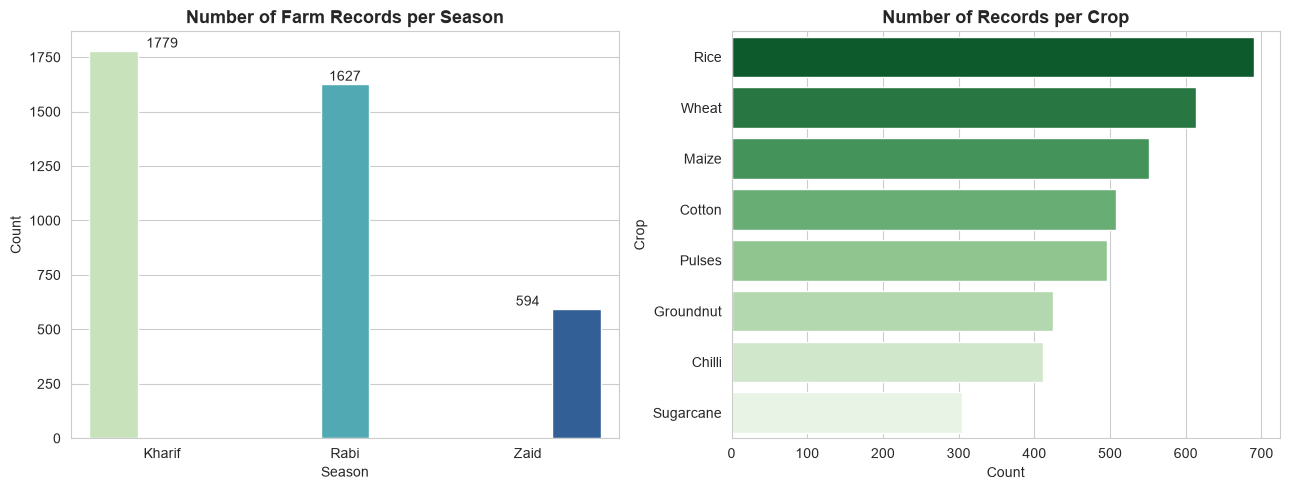

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

season_counts = df["Season"].value_counts().sort_index()
sns.barplot(x=season_counts.index, y=season_counts.values, hue=season_counts.index,
            palette="YlGnBu", legend=False, ax=axes[0])
axes[0].set_title("Number of Farm Records per Season")
axes[0].set_xlabel("Season"); axes[0].set_ylabel("Count")
for i, v in enumerate(season_counts.values):
    axes[0].text(i, v + 15, str(v), ha="center")

crop_counts = df["Crop"].value_counts()
sns.barplot(x=crop_counts.values, y=crop_counts.index, hue=crop_counts.index,
            palette="Greens_r", legend=False, ax=axes[1])
axes[1].set_title("Number of Records per Crop")
axes[1].set_xlabel("Count"); axes[1].set_ylabel("Crop")

plt.tight_layout()
plt.show()

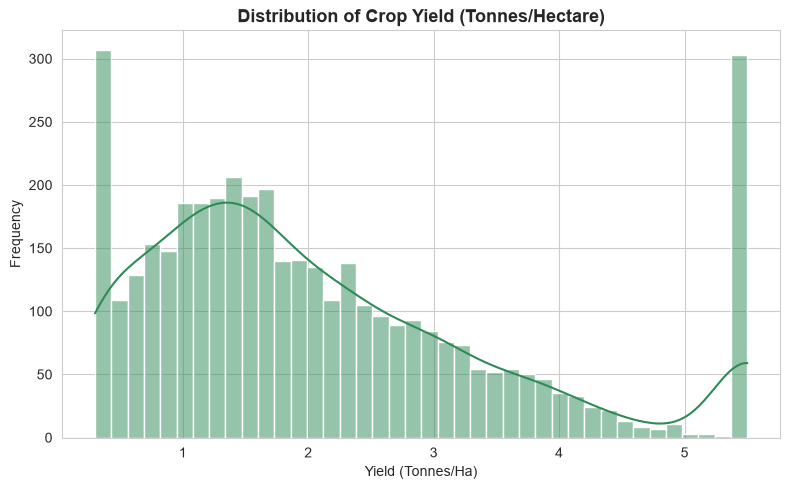

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Yield_Tonnes_Ha"], bins=40, kde=True, color="seagreen")
plt.title("Distribution of Crop Yield (Tonnes/Hectare)")
plt.xlabel("Yield (Tonnes/Ha)"); plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [13]:
season_summary = df.groupby("Season", observed=True)[
    ["Yield_Tonnes_Ha", "Profit_INR", "Revenue_INR", "Total_Cost_INR",
     "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct", "Rainfall_mm"]
].mean().round(2)
season_summary

,Yield_Tonnes_Ha,Profit_INR,Revenue_INR,Total_Cost_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Rainfall_mm
Season,,,,,,,
Kharif,2.25,178914.65,710719.06,531804.41,4.04,54.47,852.11
Rabi,2.03,87689.47,601526.05,513836.58,3.73,40.48,435.94
Zaid,1.81,-24804.82,519171.90,543976.73,3.25,38.22,299.12


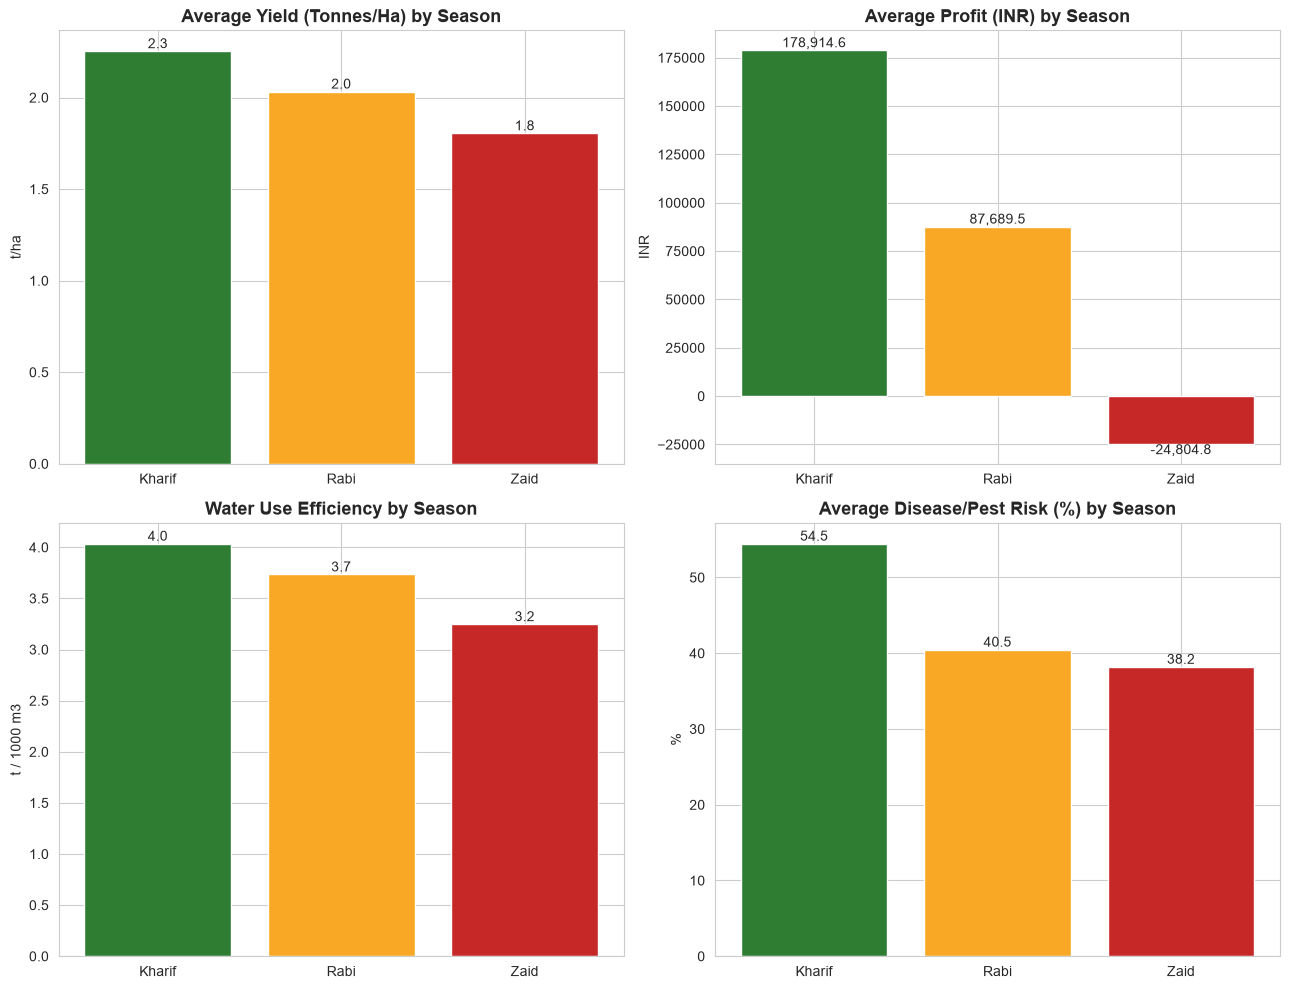

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
metrics = [
    ("Yield_Tonnes_Ha", "Average Yield (Tonnes/Ha) by Season", "t/ha"),
    ("Profit_INR", "Average Profit (INR) by Season", "INR"),
    ("Water_Efficiency_t_per_1000m3", "Water Use Efficiency by Season", "t / 1000 m3"),
    ("Disease_Pest_Risk_pct", "Average Disease/Pest Risk (%) by Season", "%"),
]
palette = {"Kharif": "#2E7D32", "Rabi": "#F9A825", "Zaid": "#C62828"}

for ax, (col, title, ylabel) in zip(axes.flat, metrics):
    means = df.groupby("Season", observed=True)[col].mean()
    colors = [palette[s] for s in means.index]
    ax.bar(means.index.astype(str), means.values, color=colors)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    for i, v in enumerate(means.values):
        ax.text(i, v, f"{v:,.1f}", ha="center", va="bottom" if v >= 0 else "top")

plt.tight_layout()

plt.show()

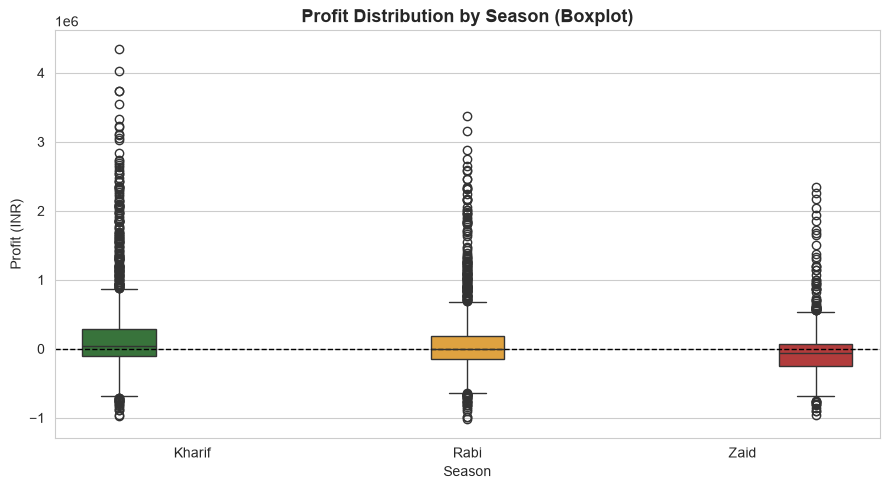

In [18]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Season", y="Profit_INR", hue="Season", palette=palette, legend=False)
plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.title("Profit Distribution by Season (Boxplot)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

In [21]:
def run_anova(metric):
    groups = [df.loc[df["Season"] == s, metric].dropna() for s in ["Kharif", "Rabi", "Zaid"]]
    f_stat, p_val = stats.f_oneway(*groups)
    result = "significant" if p_val < 0.05 else "not significant"
    print(f"{metric:35s} | F = {f_stat:8.2f} | p = {p_val:.6f} -> {result}")
    return f_stat, p_val

print("One-Way ANOVA across Kharif / Rabi / Zaid\n" + "-"*70)
for metric in ["Yield_Tonnes_Ha", "Profit_INR", "Water_Efficiency_t_per_1000m3",
               "Disease_Pest_Risk_pct", "Fertilizer_kg_ha"]:
    run_anova(metric)

One-Way ANOVA across Kharif / Rabi / Zaid
----------------------------------------------------------------------
Yield_Tonnes_Ha                     | F =    25.42 | p = 0.000000 -> significant
Profit_INR                          | F =    34.29 | p = 0.000000 -> significant
Water_Efficiency_t_per_1000m3       | F =    17.49 | p = 0.000000 -> significant
Disease_Pest_Risk_pct               | F =  1049.47 | p = 0.000000 -> significant
Fertilizer_kg_ha                    | F =     0.51 | p = 0.597979 -> not significant


## Relationships Between Environmental Conditions and Performance

Next we examine how environmental factors (rainfall, temperature) relate to yield,
and whether that relationship differs by season — using correlation and scatter
plots with regression trend lines.

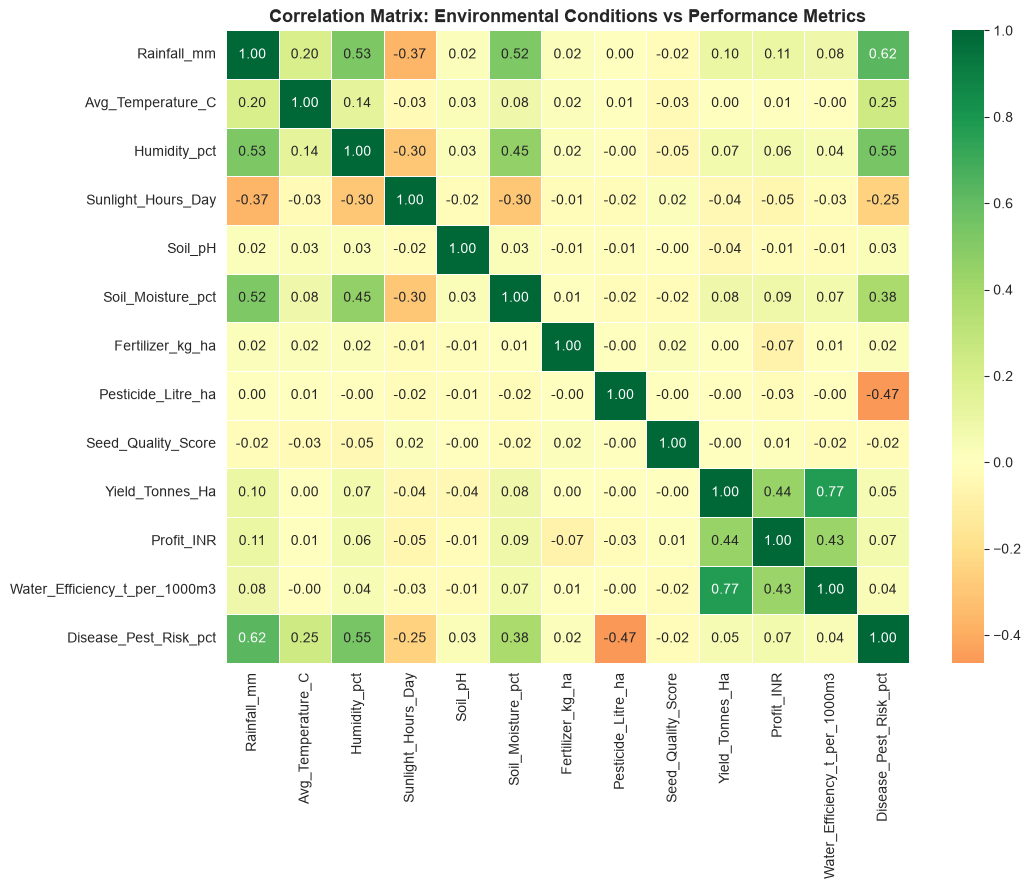

In [22]:
numeric_cols = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Sunlight_Hours_Day",
                 "Soil_pH", "Soil_Moisture_pct", "Fertilizer_kg_ha", "Pesticide_Litre_ha",
                 "Seed_Quality_Score", "Yield_Tonnes_Ha", "Profit_INR",
                 "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct"]

corr = df[numeric_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, linewidths=0.5)
plt.title("Correlation Matrix: Environmental Conditions vs Performance Metrics")
plt.tight_layout()
plt.show()

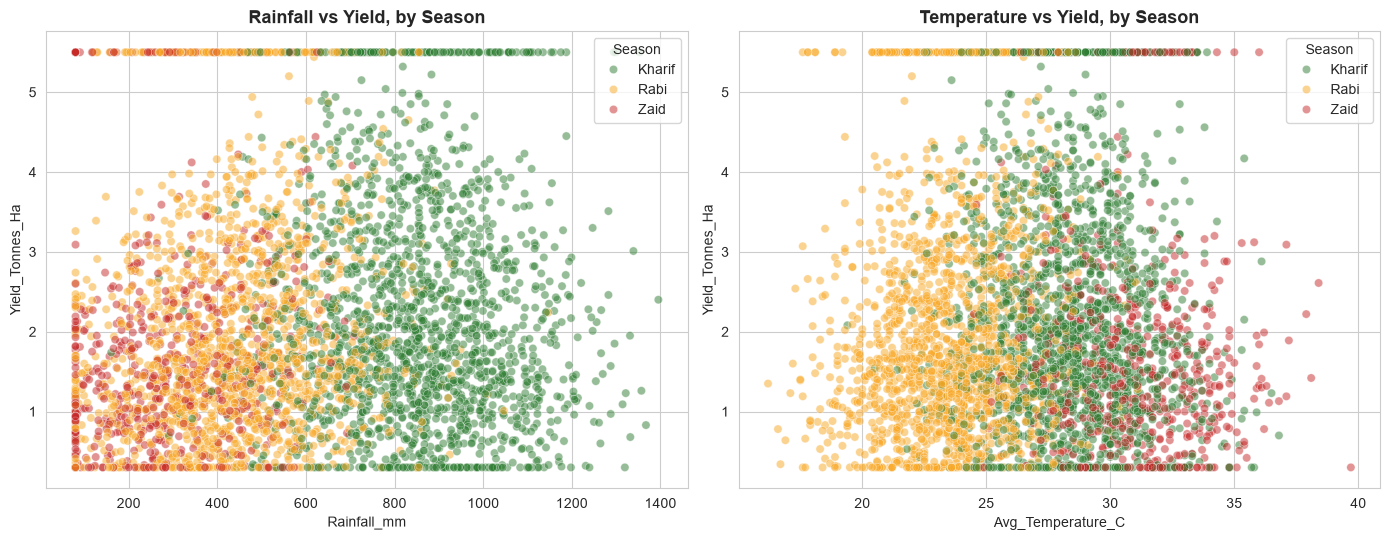

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season",
                 palette=palette, alpha=0.5, ax=axes[0])
axes[0].set_title("Rainfall vs Yield, by Season")

sns.scatterplot(data=df, x="Avg_Temperature_C", y="Yield_Tonnes_Ha", hue="Season",
                 palette=palette, alpha=0.5, ax=axes[1])
axes[1].set_title("Temperature vs Yield, by Season")

plt.tight_layout()
plt.show()

## Resource Usage Across Seasons

How do irrigation choices, fertilizer use, pesticide use and water consumption
change from season to season?

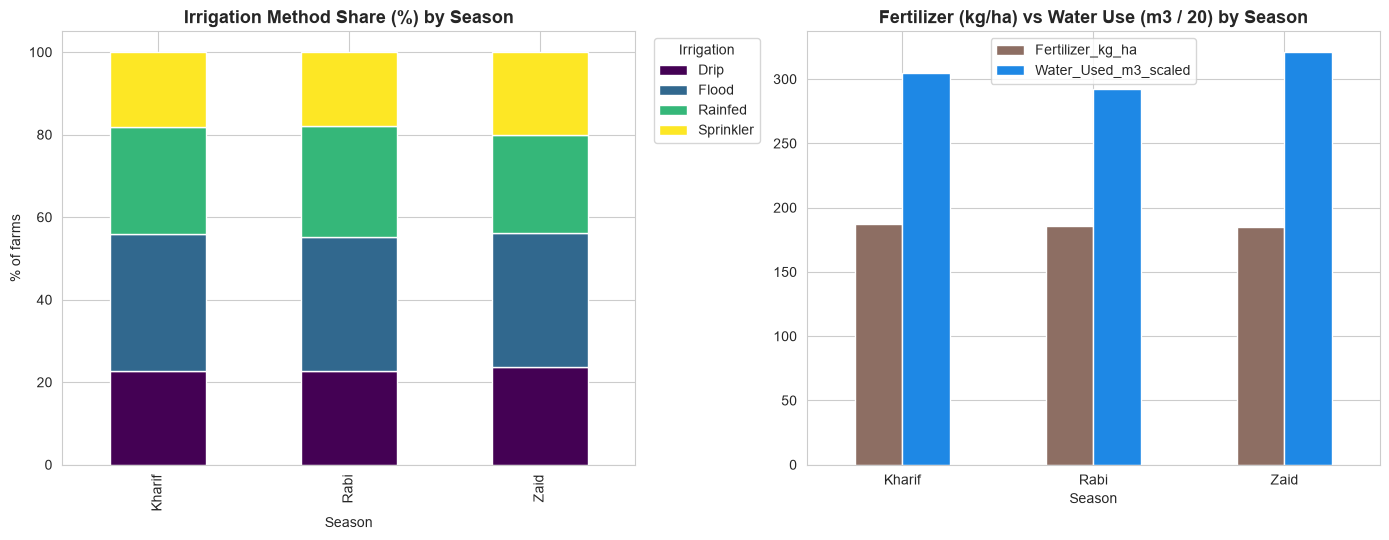

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

irrigation_season = pd.crosstab(df["Season"], df["Irrigation_Method"], normalize="index") * 100
irrigation_season.plot(kind="bar", stacked=True, ax=axes[0],
                        colormap="viridis")
axes[0].set_title("Irrigation Method Share (%) by Season")
axes[0].set_ylabel("% of farms")
axes[0].legend(title="Irrigation", bbox_to_anchor=(1.02, 1), loc="upper left")

resource_means = df.groupby("Season", observed=True)[
    ["Fertilizer_kg_ha", "Water_Used_m3"]].mean()
resource_means["Water_Used_m3_scaled"] = resource_means["Water_Used_m3"] / 20  # scale for dual comparison
resource_means[["Fertilizer_kg_ha", "Water_Used_m3_scaled"]].plot(
    kind="bar", ax=axes[1], color=["#8D6E63", "#1E88E5"])
axes[1].set_title("Fertilizer (kg/ha) vs Water Use (m3 / 20) by Season")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

##  Crop-wise and Region-wise Seasonal Patterns

Are seasonal patterns consistent across different crops and states, or do specific
crop/region combinations behave differently?

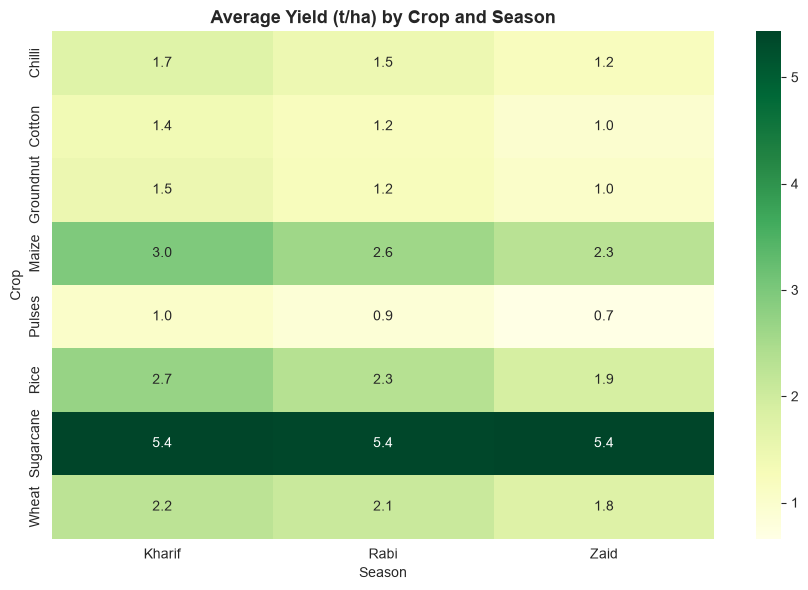

In [25]:
pivot_yield = df.pivot_table(values="Yield_Tonnes_Ha", index="Crop",
                              columns="Season", aggfunc="mean", observed=True).round(2)

plt.figure(figsize=(9, 6))
sns.heatmap(pivot_yield, annot=True, fmt=".1f", cmap="YlGn")
plt.title("Average Yield (t/ha) by Crop and Season")
plt.tight_layout()
plt.show()

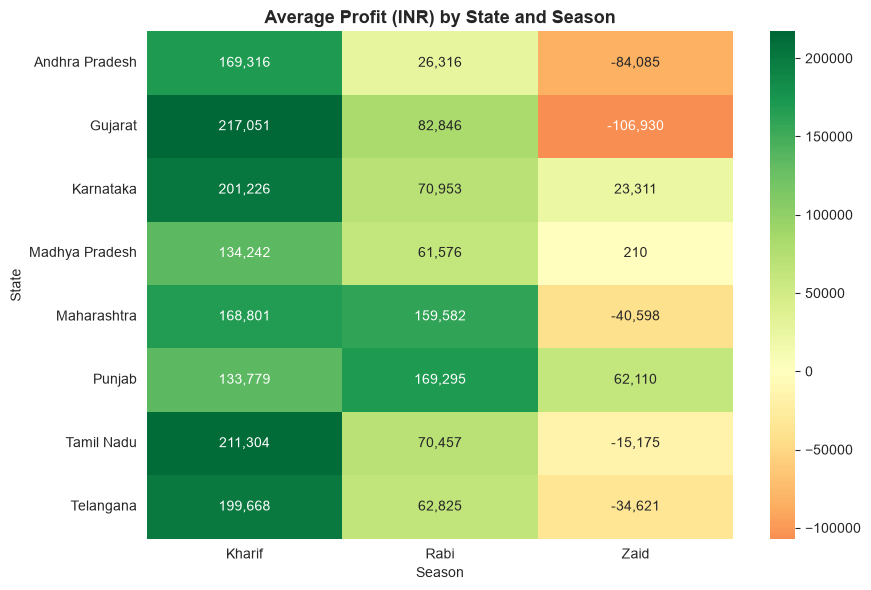

In [26]:
state_season_profit = df.pivot_table(values="Profit_INR", index="State",
                                      columns="Season", aggfunc="mean", observed=True)

plt.figure(figsize=(9, 6))
sns.heatmap(state_season_profit, annot=True, fmt=",.0f", cmap="RdYlGn", center=0)
plt.title("Average Profit (INR) by State and Season")
plt.tight_layout()
plt.show()

##  Unusual / Extreme Patterns

We flag the specific farm records with the highest losses and the highest profits
to understand what separates the best and worst performing farms in each season.

In [27]:
top_loss = df.nsmallest(5, "Profit_INR")[
    ["Farm_ID", "State", "Crop", "Season", "Yield_Tonnes_Ha", "Total_Cost_INR",
     "Revenue_INR", "Profit_INR"]]
print("5 biggest loss-making farms:")
top_loss

5 biggest loss-making farms:


,Farm_ID,State,Crop,Season,Yield_Tonnes_Ha,Total_Cost_INR,Revenue_INR,Profit_INR
780,SF10781,Andhra Pradesh,Groundnut,Rabi,0.30,1299362,280139,-1019223
2210,SF12211,Andhra Pradesh,Wheat,Rabi,0.30,1097692,102497,-995195
3625,SF13626,Punjab,Maize,Rabi,0.97,1207553,226503,-981050
2182,SF12183,Andhra Pradesh,Rice,Kharif,1.01,1297725,320865,-976860
104,SF10105,Gujarat,Wheat,Zaid,0.30,1063989,98792,-965197


In [28]:
top_profit = df.nlargest(5, "Profit_INR")[
    ["Farm_ID", "State", "Crop", "Season", "Yield_Tonnes_Ha", "Total_Cost_INR",
     "Revenue_INR", "Profit_INR"]]
print("5 most profitable farms:")
top_profit

5 most profitable farms:


,Farm_ID,State,Crop,Season,Yield_Tonnes_Ha,Total_Cost_INR,Revenue_INR,Profit_INR
2236,SF12237,Punjab,Chilli,Kharif,3.90,712027,5057448,4345421
626,SF10627,Maharashtra,Chilli,Kharif,2.92,1059050,5080900,4021850
3425,SF13426,Madhya Pradesh,Sugarcane,Kharif,5.50,745161,4485260,3740099
1690,SF11691,Karnataka,Chilli,Kharif,3.01,784135,4522464,3738329
247,SF10248,Maharashtra,Chilli,Kharif,3.09,1283161,4825365,3542204


## Conclusions & Recommendations

**Conclusions**
1. Season is a statistically significant driver of yield, profit, water efficiency
   and disease/pest risk in this dataset.
2. Kharif is the most productive and profitable season; Zaid is the most
   financially risky, running an average net loss.
3. Rainfall availability is the single strongest environmental driver of yield
   differences between seasons.
4. Irrigation strategy (not just rainfall) meaningfully affects outcomes — efficient
   irrigation can partially close the seasonal performance gap.

**Recommendations**
1. Expand drip/sprinkler irrigation subsidies specifically for Zaid-season farms
   to reduce dependency on rainfall.
2. Re-evaluate crop selection for the Zaid season toward more drought-tolerant,
   lower-water crops.
3. Time pest/disease advisory and intervention programs to align with the higher
   Kharif-season disease/pest risk window.
4. Use season-adjusted cost-benefit planning (rather than a single annual average)
   when advising farmers on input investment.
